# Projeto Integrado: Análise de Dados de Videogames (Loja Ice)

## Sumário
1. [**Introdução e Descrição dos Dados**](#descrição-dos-dados)
2. [**Etapa 1: Preparação dos Dados**](#etapa-1-preparação-dos-dados)
   * Tratamento de nomes de colunas, valores ausentes e tipos de dados.
3. [**Etapa 2: Análise Exploratória de Dados (EDA)**](#etapa-2-análise-exploratória-de-dados-eda)
   * Ciclo de vida das plataformas e tendências de vendas.
   * Identificação do período relevante para o planejamento de 2017.
   * Correlação entre avaliações e desempenho comercial.
4. [**Etapa 3: Perfil de Usuário por Região**](#etapa-3-perfil-de-usuário-por-região)
   * Diferenças de mercado entre NA, EU e JP.
   * Impacto da classificação ESRB nas vendas regionais.
5. [**Etapa 4: Teste de Hipóteses Estatísticas**](#etapa-4-teste-de-hipóteses-estatísticas)
   * Xbox One vs. PC.
   * Gênero Action vs. Sports.
6. [**Conclusão Geral**](#conclusão-geral)

## Introdução
Este projeto tem como objetivo identificar padrões que determinam o sucesso de um videogame, utilizando dados históricos de vendas, avaliações de usuários/especialistas e plataformas. O foco principal é analisar os dados até 2016 para planejar uma campanha publicitária para 2017.

## Etapa 1: Preparação do Ambiente e Carga de Dados
Nesta etapa, vamos importar as bibliotecas necessárias e carregar o conjunto de dados para uma primeira inspeção.

## Descrição dos Dados

O conjunto de dados contém informações sobre vendas de jogos, pontuações de especialistas e usuários, e classificações etárias. Abaixo, a descrição de cada coluna:

* **Name:** Nome do jogo.
* **Platform:** Console ou plataforma de lançamento.
* **Year_of_Release:** Ano em que o jogo foi lançado.
* **Genre:** Categoria do jogo (Ação, Esportes, etc.).
* **NA_sales:** Vendas na América do Norte (em milhões de USD).
* **EU_sales:** Vendas na Europa (em milhões de USD).
* **JP_sales:** Vendas no Japão (em milhões de USD).
* **Other_sales:** Vendas no restante do mundo (em milhões de USD).
* **Critic_Score:** Pontuação da crítica especializada (escala de 0 a 100).
* **User_Score:** Pontuação dada pelos usuários (escala de 0 a 10).
* **Rating:** Classificação etária definida pelo órgão ESRB.

**Nota:** Os dados referentes ao ano de 2016 podem estar incompletos no momento da coleta, o que foi levado em consideração durante as análises de tendências.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

# Carregando os dados
try:
    df = pd.read_csv('/datasets/games.csv')
except:
    # Caso o caminho padrão falhe, tente carregar localmente
    df = pd.read_csv('games.csv')

# Visualizando as primeiras linhas e informações gerais
print("Primeiras 5 linhas do DataFrame:")
display(df.head())
print("\nInformações Gerais:")
df.info()

Primeiras 5 linhas do DataFrame:


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN



Informações Gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


#### Nomes das Colunas: 
Estão com letras maiúsculas e minúsculas misturadas. Precisamos padronizar para minúsculo.
#### Tipos de Dados: 
Year_of_Release está como float64 (número com vírgula), mas anos são números inteiros. User_Score está como object (texto), mas deveria ser numérico para fazermos cálculos.
#### Valores Ausentes: 
Há muitos valores nulos em Critic_Score, User_Score e Rating.

## Etapa 2: Preparação dos dados

### 2.1. Padronização dos nomes das colunas
Para facilitar a manipulação dos dados e seguir as boas práticas de programação, vamos converter todos os nomes das colunas para letras minúsculas.

### 2.2. Conversão de tipos e tratamento de valores ausentes
Identificamos que a coluna 'year_of_release' contém valores nulos e está no formato float. Como não é possível converter valores nulos (NaN) para o tipo inteiro (int) diretamente, e o volume de dados ausentes em 'name' e 'year_of_release' é pequeno, optaremos por remover essas linhas para garantir a integridade da análise temporal.

In [2]:
# 1. Transformando nomes das colunas em minúsculo
df.columns = df.columns.str.lower()

# 2. Removendo linhas com valores ausentes em colunas críticas (nome e ano)
# Como são poucos registros (apenas 2 nomes e cerca de 269 anos), a exclusão não afetará a análise.
df.dropna(subset=['name', 'year_of_release'], inplace=True)

# 3. Convertendo o ano para inteiro
df['year_of_release'] = df['year_of_release'].astype(int)

# Verificando as mudanças
print("Colunas atualizadas:", df.columns.tolist())
print("\nNovos tipos de dados:")
print(df.dtypes[['name', 'year_of_release']])

Colunas atualizadas: ['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']

Novos tipos de dados:
name               object
year_of_release     int64
dtype: object


### 2.3. Tratamento da coluna 'user_score' (TBD)
A abreviação "TBD" significa que a nota ainda será determinada. Para fins de análise estatística, trataremos esses valores como nulos (NaN), permitindo a conversão da coluna para o tipo numérico (float).

### 2.4. Cálculo do Total de Vendas
Conforme solicitado nas instruções, criaremos uma coluna denominada 'total_sales', que representa a soma das vendas nas regiões: América do Norte, Europa, Japão e outros países.

In [3]:
# 1. Tratando o "TBD" na coluna user_score
# Substituímos 'tbd' por NaN e convertemos para float
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

# 2. Calculando o total de vendas (soma das colunas de vendas regionais)
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

# Verificando o resultado
print("Verificação de tipos após conversão:")
print(df[['user_score', 'total_sales']].dtypes)
print("\nPrimeiras linhas com a nova coluna 'total_sales':")
display(df[['name', 'platform', 'total_sales']].head())

Verificação de tipos após conversão:
user_score     float64
total_sales    float64
dtype: object

Primeiras linhas com a nova coluna 'total_sales':


,name,platform,total_sales
0,Wii Sports,Wii,82.54
1,Super Mario Bros.,NES,40.24
2,Mario Kart Wii,Wii,35.52
3,Wii Sports Resort,Wii,32.77
4,Pokemon Red/Pokemon Blue,GB,31.38


## Etapa 3: Análise exploratória de dados

### 3.1. Quantidade de jogos lançados por ano
Para entender o comportamento do mercado ao longo do tempo, vamos verificar quantos jogos foram lançados em cada período. Isso nos ajudará a decidir se os dados de todos os períodos são significativos para prever o sucesso de um jogo em 2017.

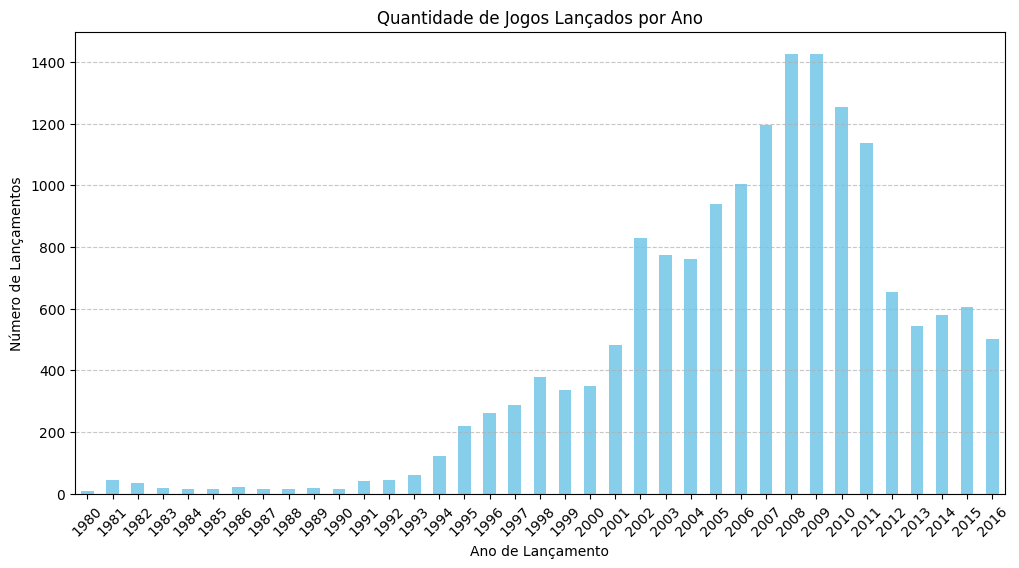

Lançamentos nos últimos 10 anos registrados:
year_of_release
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64


In [4]:
# Agrupando os jogos por ano de lançamento e contando a quantidade
games_per_year = df.groupby('year_of_release')['name'].count()

# Criando o gráfico de barras
plt.figure(figsize=(12, 6))
games_per_year.plot(kind='bar', color='skyblue', rot='45')
plt.title('Quantidade de Jogos Lançados por Ano')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Número de Lançamentos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Exibindo os números absolutos dos anos mais recentes para análise
print("Lançamentos nos últimos 10 anos registrados:")
print(games_per_year.tail(10))

### 3.2. Vendas por plataforma e ciclo de vida
Vamos identificar as plataformas com as maiores vendas totais para entender como a popularidade de cada console evolui ao longo do tempo. Esta análise nos permitirá determinar o tempo médio que uma plataforma leva para surgir e desaparecer do mercado.

Top 10 plataformas em vendas totais:
platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64


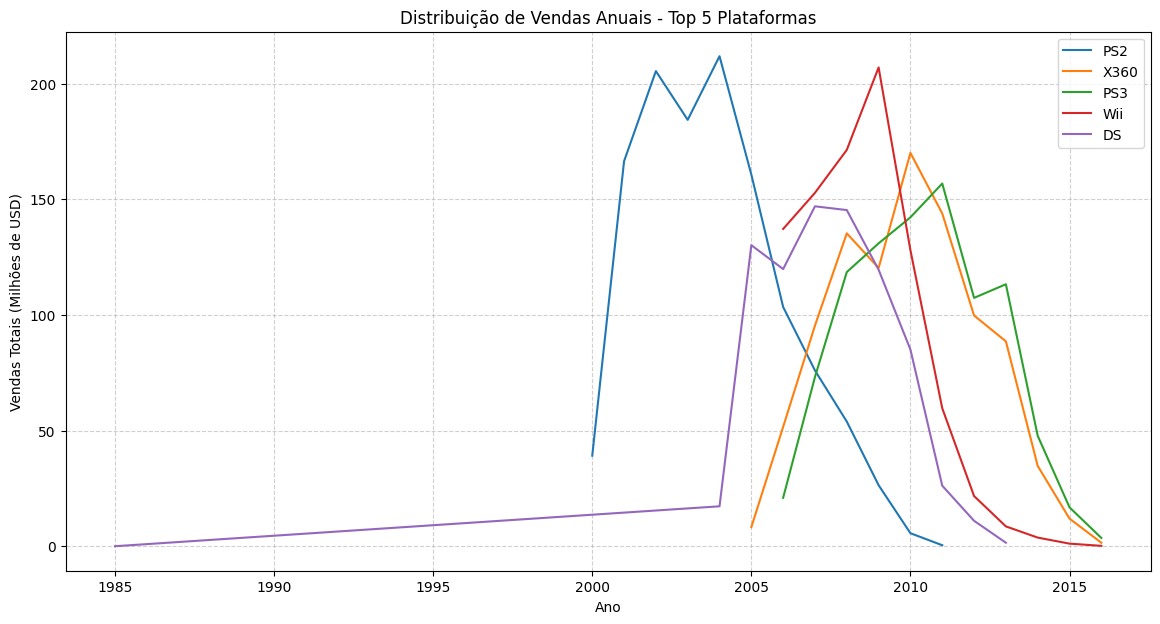

In [5]:
# 1. Identificando as 10 plataformas com maiores vendas totais
top_platforms = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 plataformas em vendas totais:")
print(top_platforms)

# 2. Criando uma distribuição de vendas anuais para as 5 principais plataformas
top_5_list = top_platforms.head(5).index.tolist()

plt.figure(figsize=(14, 7))
for platform in top_5_list:
    yearly_sales = df[df['platform'] == platform].groupby('year_of_release')['total_sales'].sum()
    yearly_sales.plot(label=platform)

plt.title('Distribuição de Vendas Anuais - Top 5 Plataformas')
plt.xlabel('Ano')
plt.ylabel('Vendas Totais (Milhões de USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 3.3. Definição do período relevante para análise
Considerando que o ciclo de vida das plataformas é de aproximadamente 10 anos e que precisamos planejar uma campanha para 2017, selecionaremos apenas os dados a partir de 2014. Este recorte permite focar em consoles da geração atual (PS4, Xbox One) e identificar tendências de crescimento ou declínio que ainda estarão vigentes no próximo ano.

### 3.4. Plataformas potenciais para 2017
Vamos analisar quais plataformas lideram em vendas no período selecionado e quais apresentam potencial de lucro.

### 3.5. Comparação de Vendas Globais por Plataforma (Boxplot)
Para entender melhor a distribuição das vendas, utilizaremos diagramas de caixa (boxplots). Eles nos permitem visualizar não apenas a média de vendas, mas também a variação (dispersão) e os valores atípicos (outliers), que representam os grandes sucessos comerciais em cada plataforma.

In [7]:
# Após reiniciar o Kernel, tive um erro, por isso filtrei os dados para essa análise
# Filtrando dados para o período relevante (2014-2016)

df_recent = df[df['year_of_release'] >= 2014]

print(f"Dados originais: {len(df)} registros")
print(f"Dados recentes (2014-2016): {len(df_recent)} registros")

Dados originais: 16444 registros
Dados recentes (2014-2016): 1689 registros


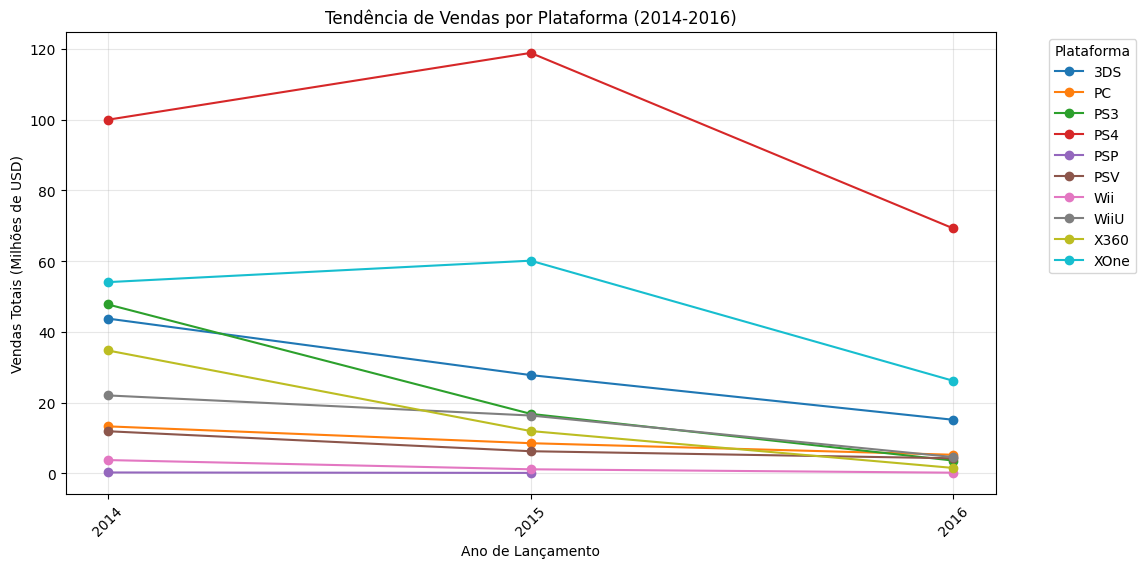

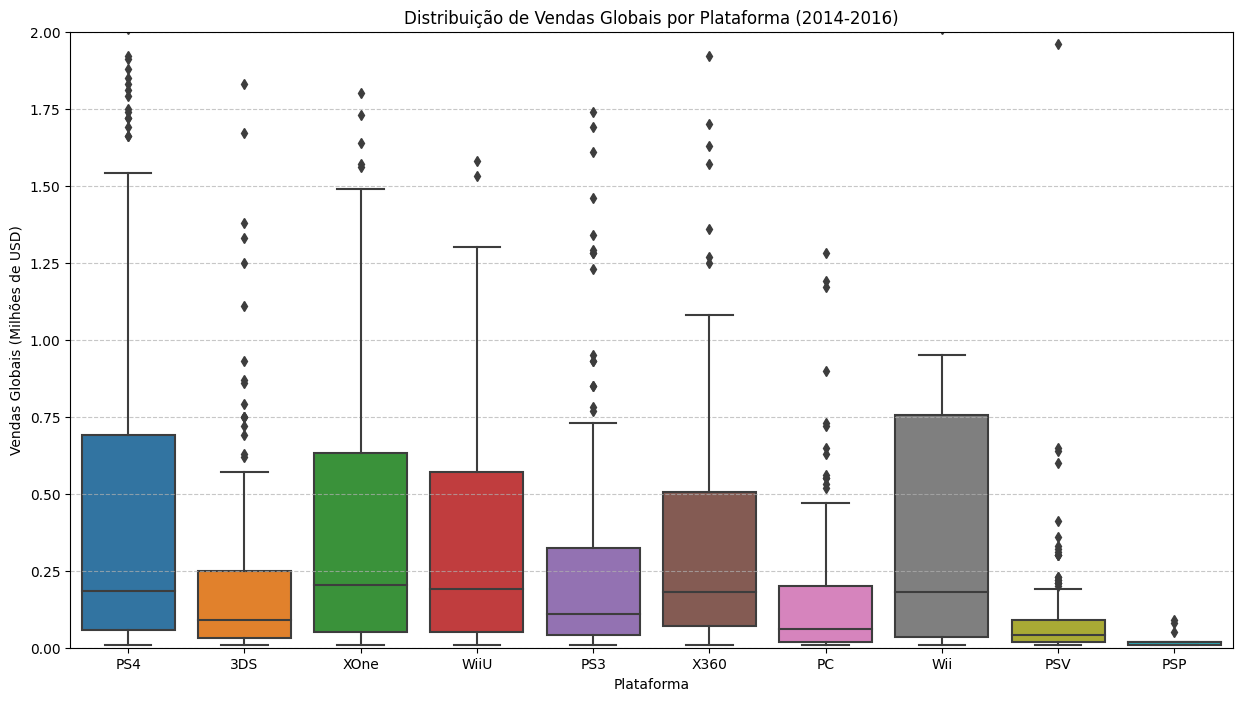

In [8]:
# 1. Gráfico de Tendências com Eixo X corrigido e Rotação
pivot_recent = df_recent.pivot_table(index='year_of_release', 
                                    columns='platform', 
                                    values='total_sales', 
                                    aggfunc='sum')

plt.figure(figsize=(12, 6))
for platform in pivot_recent.columns:
    plt.plot(pivot_recent.index, pivot_recent[platform], marker='o', label=platform)

# Ajustando o Eixo X para mostrar apenas anos inteiros e rotacionar
plt.xticks(pivot_recent.index, rotation=45) 
plt.title('Tendência de Vendas por Plataforma (2014-2016)')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Vendas Totais (Milhões de USD)')
plt.legend(title='Plataforma', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Criando o Boxplot para vendas globais por plataforma
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_recent, x='platform', y='total_sales')
plt.title('Distribuição de Vendas Globais por Plataforma (2014-2016)')
plt.xlabel('Plataforma')
plt.ylabel('Vendas Globais (Milhões de USD)')
# Limitando o eixo Y para melhor visualização, pois existem sucessos muito fora da curva
plt.ylim(0, 2) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3.6. Análise dos Diagramas de Caixa (Boxplots)
Ao analisar os boxplots de vendas globais por plataforma no período de 2014-2016, observamos que:
* As vendas médias (medianas) da maioria das plataformas são relativamente baixas, concentradas abaixo de 250 mil cópias por jogo.
* No entanto, plataformas como **PS4** e **XOne** possuem boxplots com áreas maiores e muitos valores atípicos (outliers), o que indica uma frequência maior de "blockbusters" que vendem milhões de cópias.
* A diferença entre as vendas médias e as vendas totais sugere que o sucesso no mercado de games é fortemente impulsionado por um pequeno número de títulos extremamente populares.

### 3.7. Impacto das avaliações nas vendas (Estudo de Caso: PS4)
Para entender se as notas de críticos e usuários influenciam o sucesso comercial, analisaremos a plataforma PS4. Utilizaremos gráficos de dispersão para visualizar essa relação e calcularemos o coeficiente de correlação de Pearson para medir a força dessa associação.

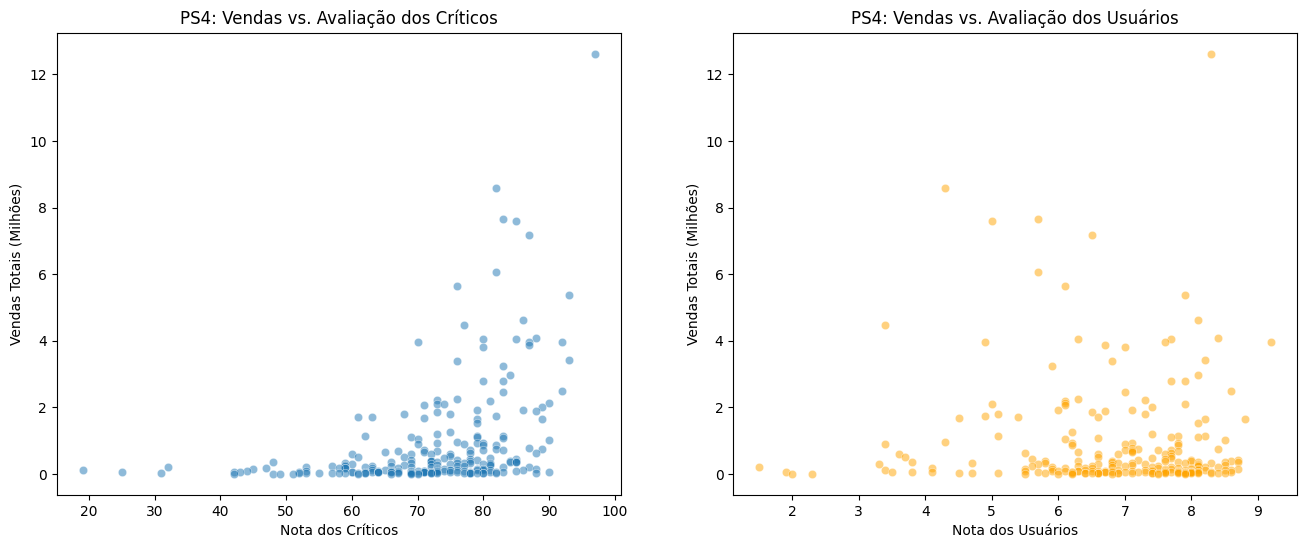

Correlação entre Vendas e Críticos: 0.40
Correlação entre Vendas e Usuários: -0.04


In [9]:
# 1. Filtrando dados apenas do PS4 e removendo nulos nas notas para o cálculo
ps4_data = df_recent[(df_recent['platform'] == 'PS4') & 
                     (df_recent['critic_score'].notna()) & 
                     (df_recent['user_score'].notna())]

# 2. Criando os gráficos de dispersão
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Vendas vs. Avaliação dos Críticos
sns.scatterplot(data=ps4_data, x='critic_score', y='total_sales', ax=ax[0], alpha=0.5)
ax[0].set_title('PS4: Vendas vs. Avaliação dos Críticos')
ax[0].set_xlabel('Nota dos Críticos')
ax[0].set_ylabel('Vendas Totais (Milhões)')

# Vendas vs. Avaliação dos Usuários
sns.scatterplot(data=ps4_data, x='user_score', y='total_sales', ax=ax[1], alpha=0.5, color='orange')
ax[1].set_title('PS4: Vendas vs. Avaliação dos Usuários')
ax[1].set_xlabel('Nota dos Usuários')
ax[1].set_ylabel('Vendas Totais (Milhões)')

plt.show()

# 3. Calculando a correlação
corr_critic = ps4_data['critic_score'].corr(ps4_data['total_sales'])
corr_user = ps4_data['user_score'].corr(ps4_data['total_sales'])

print(f"Correlação entre Vendas e Críticos: {corr_critic:.2f}")
print(f"Correlação entre Vendas e Usuários: {corr_user:.2f}")

### 3.8. Comparação de correlação entre diferentes plataformas
Para verificar se as conclusões obtidas no PS4 são uma tendência de mercado, analisaremos a correlação entre avaliações e vendas nas plataformas Xbox One (XOne) e PC. Isso nos ajudará a entender se o impacto das críticas profissionais é um padrão global.

In [10]:
# Função para calcular correlação rapidamente em diferentes plataformas
def check_correlation(platform_name):
    temp_df = df_recent[(df_recent['platform'] == platform_name) & 
                        (df_recent['critic_score'].notna()) & 
                        (df_recent['user_score'].notna())]
    
    corr_critic = temp_df['critic_score'].corr(temp_df['total_sales'])
    corr_user = temp_df['user_score'].corr(temp_df['total_sales'])
    
    print(f"--- Plataforma: {platform_name} ---")
    print(f"Correlação Vendas vs. Críticos: {corr_critic:.2f}")
    print(f"Correlação Vendas vs. Usuários: {corr_user:.2f}\n")

# Testando para XOne e PC
check_correlation('XOne')
check_correlation('PC')

--- Plataforma: XOne ---
Correlação Vendas vs. Críticos: 0.42
Correlação Vendas vs. Usuários: -0.09

--- Plataforma: PC ---
Correlação Vendas vs. Críticos: 0.17
Correlação Vendas vs. Usuários: -0.09



### 3.8. Comparação de correlação entre diferentes plataformas
Após analisar o PS4, é fundamental verificar se o impacto das avaliações profissionais nas vendas é um fenômeno isolado ou uma tendência de mercado. Para isso, aplicaremos a mesma análise estatística para as plataformas Xbox One (XOne) e PC, comparando os coeficientes de correlação de Pearson entre vendas globais e as notas de críticos e usuários.

### 3.9. Análise de vendas por gênero
Para finalizar a análise exploratória, examinaremos a distribuição de jogos por gênero. O objetivo é identificar quais categorias são mais lucrativas e se existe uma diferença significativa entre o número de lançamentos e o volume de vendas em cada gênero.

Análise de vendas por Gênero (Ordenado pela Mediana):


,count,sum,mean,median
genre,,,,
Shooter,128,170.94,1.335469,0.515
Sports,161,109.48,0.680000,0.180
Platform,38,18.09,0.476053,0.140
Fighting,60,28.22,0.470333,0.125
Role-Playing,221,101.44,0.459005,0.110
Simulation,44,13.13,0.298409,0.100
Action,619,199.36,0.322068,0.090
Misc,113,37.55,0.332301,0.090
Racing,69,27.52,0.398841,0.090


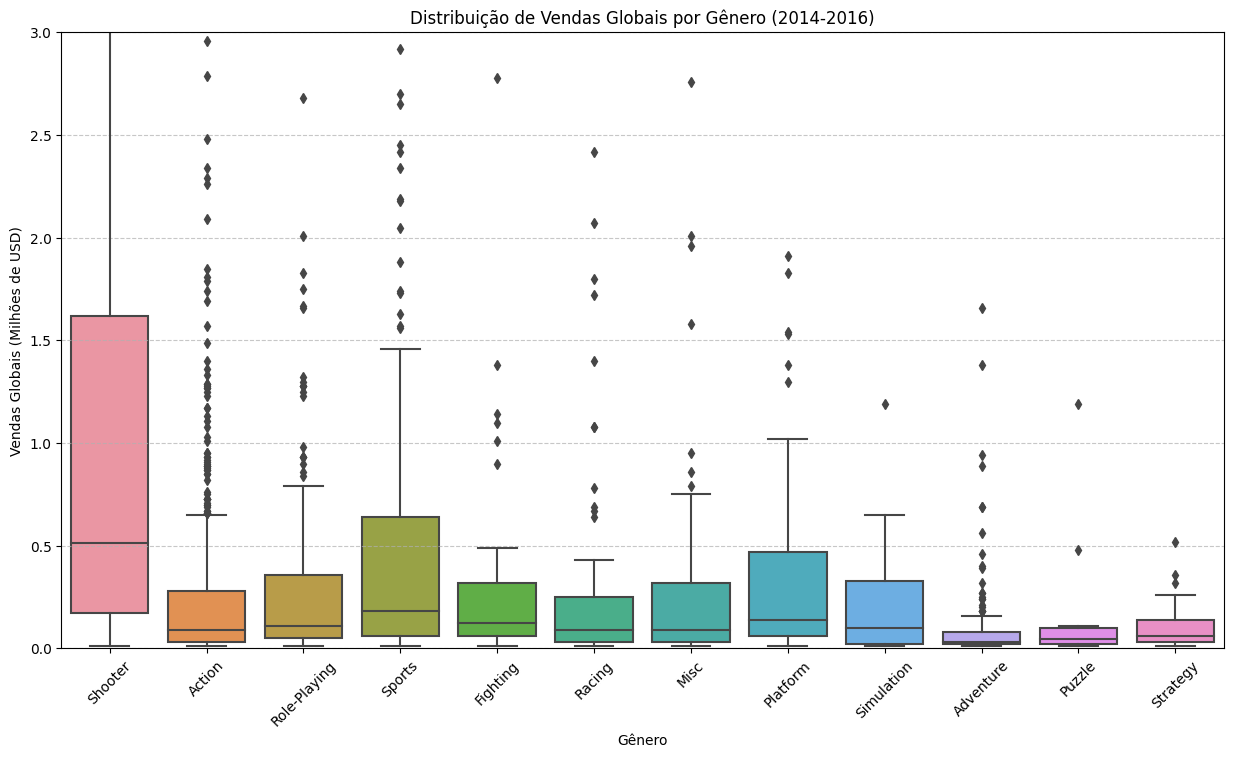

In [11]:
# 1. Agrupando por gênero e calculando métricas de vendas
genre_analysis = df_recent.groupby('genre')['total_sales'].agg(['count', 'sum', 'mean', 'median']).sort_values(by='median', ascending=False)

print("Análise de vendas por Gênero (Ordenado pela Mediana):")
display(genre_analysis)

# 2. Visualizando a distribuição de vendas por gênero (Boxplot)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_recent, x='genre', y='total_sales')
plt.title('Distribuição de Vendas Globais por Gênero (2014-2016)')
plt.xlabel('Gênero')
plt.ylabel('Vendas Globais (Milhões de USD)')
plt.ylim(0, 3) # Limite para ver melhor as caixas
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3.10. Conclusões da Análise por Gênero
Com base nos dados e no diagrama de caixa, podemos concluir:
* O gênero **Shooter** lidera em termos de rentabilidade típica (maior mediana), sugerindo que jogos de tiro têm uma performance comercial mais consistente no mercado atual.
* O gênero **Action** possui o maior volume total de vendas e de lançamentos, porém sua mediana é significativamente menor, indicando um mercado saturado com muitos títulos de baixo desempenho.
* Gêneros como **Adventure** e **Puzzle** apresentam as menores rentabilidades, sendo considerados investimentos de maior risco para a campanha de 2017.

## Etapa 4: Perfil de usuário por região

Nesta etapa, vamos analisar as preferências dos consumidores em três regiões distintas: América do Norte (NA), Europa (EU) e Japão (JP). O objetivo é identificar variações nas quotas de mercado das plataformas e nos gêneros mais populares, permitindo uma estratégia de marketing personalizada para cada território.

### 4.1. As cinco principais plataformas por região
Vamos determinar quais plataformas lideram as vendas em cada região para entender as variações de mercado.

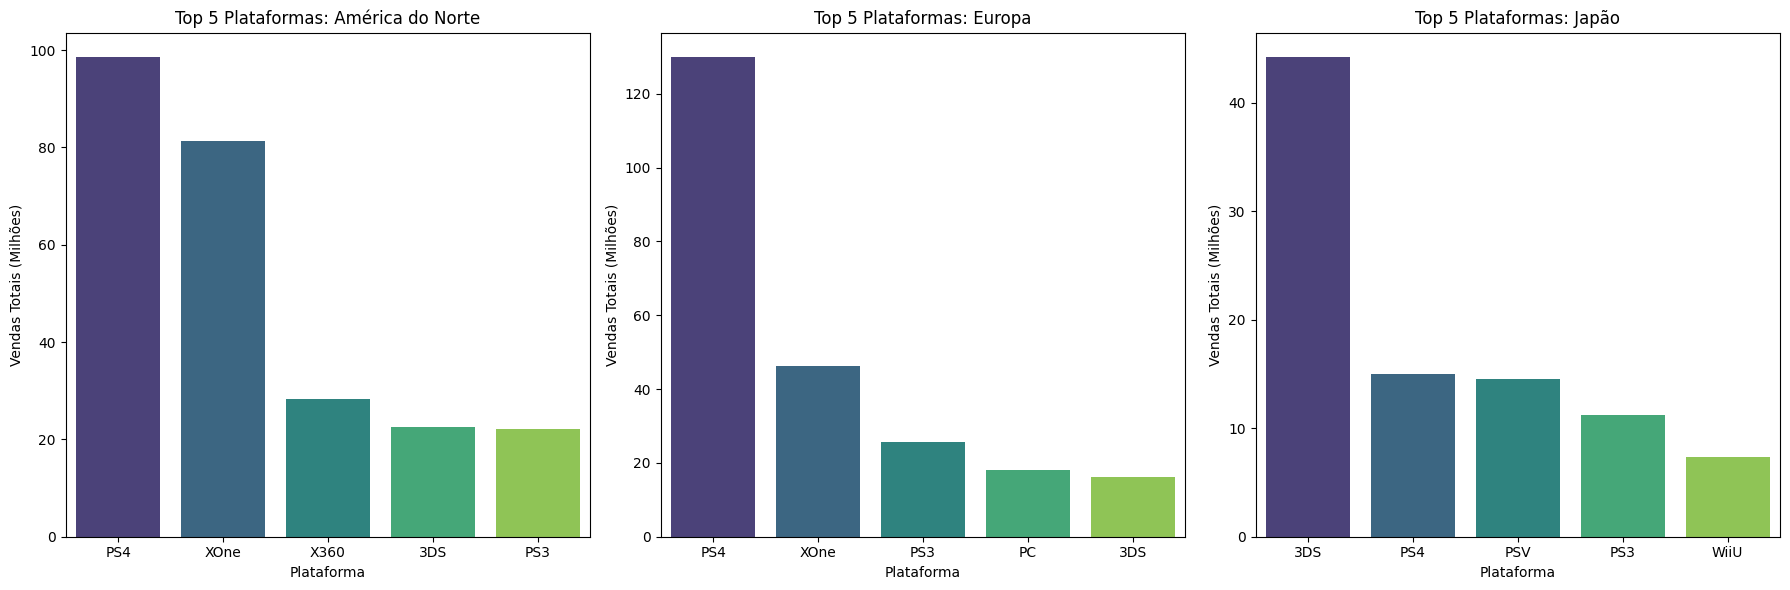


--- Região: NA_SALES ---


,Vendas (M),Share (%)
platform,,
PS4,98.61,34.714497
XOne,81.27,28.610153
X360,28.30,9.962684
3DS,22.64,7.970147
PS3,22.05,7.762445



--- Região: EU_SALES ---


,Vendas (M),Share (%)
platform,,
PS4,130.04,48.041968
XOne,46.25,17.086597
PS3,25.54,9.435496
PC,17.97,6.638836
3DS,16.12,5.955372



--- Região: JP_SALES ---


,Vendas (M),Share (%)
platform,,
3DS,44.24,47.523902
PS4,15.02,16.134923
PSV,14.54,15.619293
PS3,11.22,12.052852
WiiU,7.31,7.852616


In [12]:

# Preparando o ambiente para múltiplos gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
regions = ['na_sales', 'eu_sales', 'jp_sales']
titles = ['América do Norte', 'Europa', 'Japão']

for i, region in enumerate(regions):
    # Obtendo os dados
    top_platforms = df_recent.groupby('platform')[region].sum().sort_values(ascending=False).head(5)
    
    # Criando o gráfico de barras
    sns.barplot(x=top_platforms.index, y=top_platforms.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top 5 Plataformas: {titles[i]}')
    axes[i].set_ylabel('Vendas Totais (Milhões)')
    axes[i].set_xlabel('Plataforma')

plt.tight_layout()
plt.show()

# Exibindo as tabelas logo abaixo para detalhamento numérico
for region in regions:
    top_platforms_region = df_recent.groupby('platform')[region].sum().sort_values(ascending=False).head(5)
    total_region_sales = df_recent[region].sum()
    market_share = (top_platforms_region / total_region_sales) * 100
    
    print(f"\n--- Região: {region.upper()} ---")
    report = pd.DataFrame({'Vendas (M)': top_platforms_region, 'Share (%)': market_share})
    display(report)

### 4.2. Análise das quotas de mercado por plataforma
Ao analisar as cinco principais plataformas em cada região, observamos discrepâncias significativas:
* **América do Norte e Europa:** O mercado é dominado pelo PS4 e Xbox One. Na Europa, a dominância do PS4 é ainda mais acentuada (48% de share contra 34% na AN).
* **Japão:** O cenário é inversamente proporcional. O console portátil Nintendo 3DS lidera isoladamente com quase metade do mercado (47.5%), enquanto o Xbox One sequer aparece no Top 5.
* **Conclusão:** Campanhas de marketing para 2017 devem focar em consoles de mesa para o Ocidente e em plataformas portáteis para o mercado japonês.

### 4.3. Análise comparativa de gêneros por região
Para identificar os padrões de consumo cultural, vamos comparar os cinco gêneros mais vendidos em cada região. Utilizaremos um gráfico de barras agrupadas para visualizar como a preferência por determinados gêneros se comporta em diferentes mercados globais.

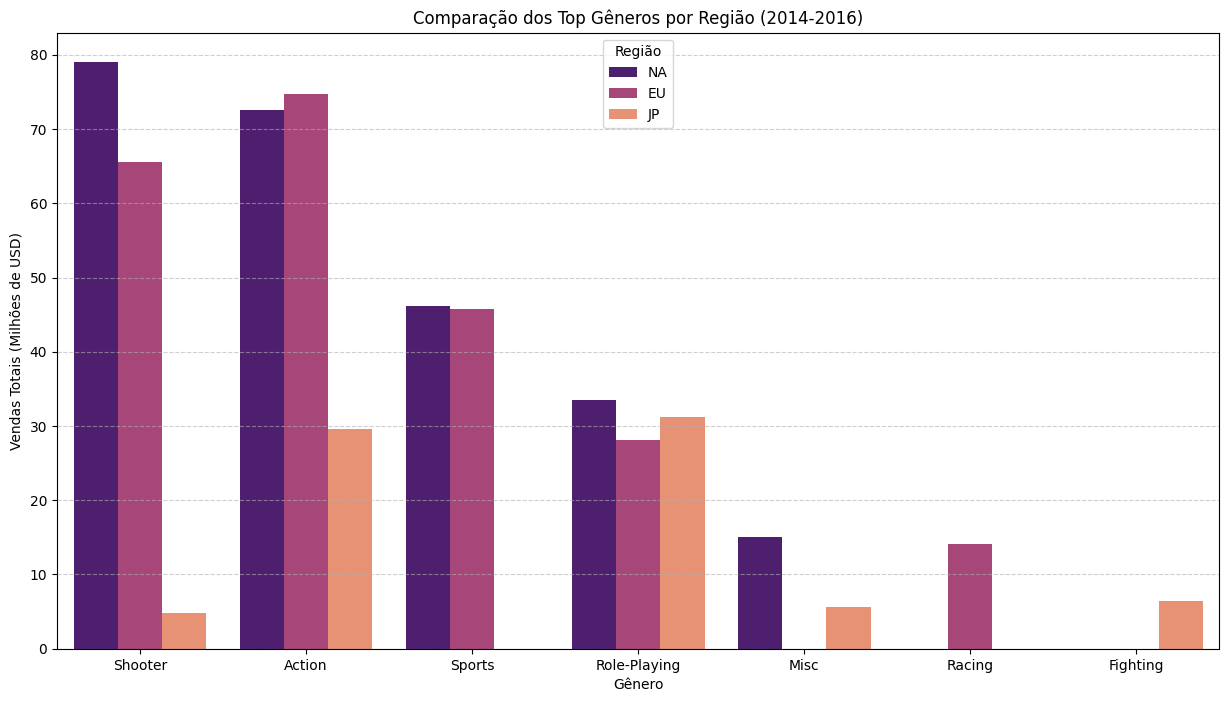


--- Top 5 Gêneros: NA_SALES ---


genre
Shooter         79.02
Action          72.53
Sports          46.13
Role-Playing    33.47
Misc            15.05
Name: na_sales, dtype: float64


--- Top 5 Gêneros: EU_SALES ---


genre
Action          74.68
Shooter         65.52
Sports          45.73
Role-Playing    28.17
Racing          14.13
Name: eu_sales, dtype: float64


--- Top 5 Gêneros: JP_SALES ---


genre
Role-Playing    31.16
Action          29.58
Fighting         6.37
Misc             5.61
Shooter          4.87
Name: jp_sales, dtype: float64

In [13]:
# Preparando os dados para um gráfico único
# Vamos pegar os top 5 de cada região e unir em um DataFrame para o gráfico
genre_data = []
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    top_genres = df_recent.groupby('genre')[region].sum().sort_values(ascending=False).head(5)
    for genre, sales in top_genres.items():
        genre_data.append({'Region': region.replace('_sales', '').upper(), 'Genre': genre, 'Sales': sales})

df_genres_comp = pd.DataFrame(genre_data)

# Criando o gráfico de barras agrupadas
plt.figure(figsize=(15, 8))
sns.barplot(data=df_genres_comp, x='Genre', y='Sales', hue='Region', palette='magma')

plt.title('Comparação dos Top Gêneros por Região (2014-2016)')
plt.xlabel('Gênero')
plt.ylabel('Vendas Totais (Milhões de USD)')
plt.legend(title='Região')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Exibindo as tabelas individuais para precisão
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    print(f"\n--- Top 5 Gêneros: {region.upper()} ---")
    display(df_recent.groupby('genre')[region].sum().sort_values(ascending=False).head(5))

### 4.3. Análise comparativa de gêneros por região
Nesta etapa, identificamos as preferências culturais de cada mercado. Observamos que:
* **América do Norte e Europa:** O gênero **Shooter** é extremamente dominante em vendas, refletindo uma preferência ocidental por jogos de ação intensa e competitiva.
* **Japão:** O gênero **Shooter** aparece apenas na última posição do Top 5. O mercado japonês é liderado pelo gênero **Role-Playing (RPG)**, que possui um apelo cultural muito mais forte naquela região.
* **Conclusão:** Para a campanha de 2017, a Ice deve focar orçamentos de marketing de 'Shooters' no Ocidente, enquanto no Japão o investimento deve ser concentrado em títulos de RPG.

### 4.4. Influência da classificação ESRB nas vendas regionais
A classificação do ESRB indica a faixa etária recomendada para cada jogo. Analisaremos se essas etiquetas afetam o volume de vendas de forma diferente em cada região. Um ponto crucial é a categoria 'Unknown', que representa jogos sem classificação ESRB — algo muito comum no Japão, onde o sistema local (CERO) é o mais utilizado.

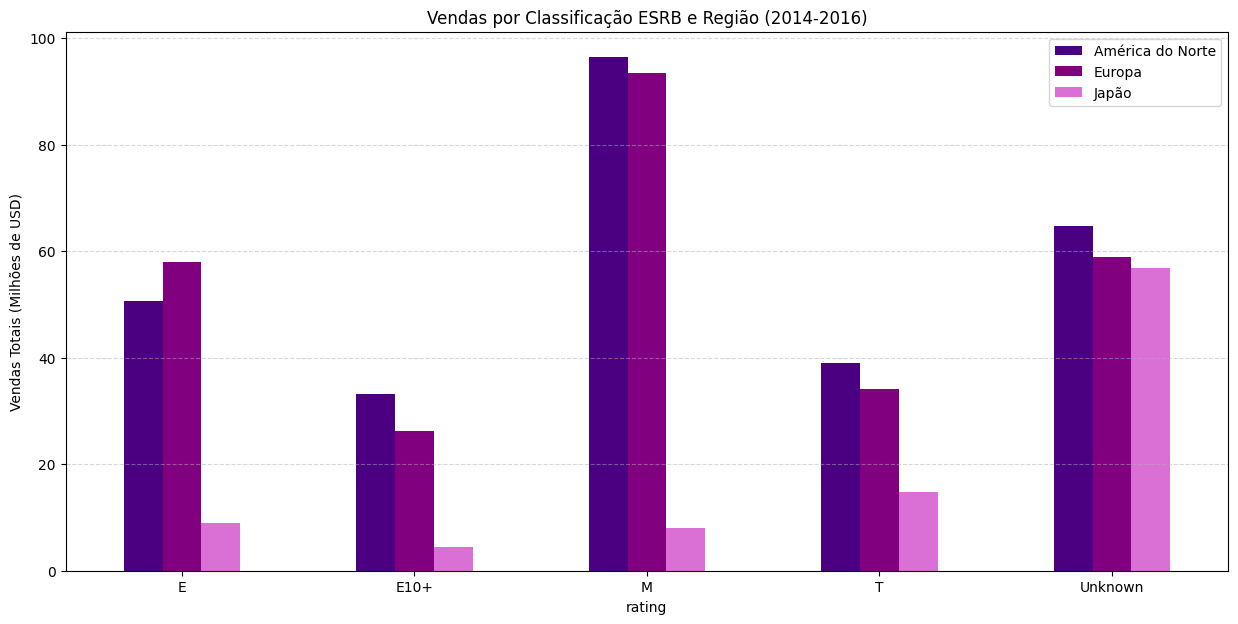

In [15]:
# Para corrigir erro após reinicio do Kernel:
# Quando criar df_recent, adicione .copy()
df_recent = df[df['year_of_release'] >= 2014].copy()  # ✅ Cria uma cópia independente

# Agora pode modificar sem warning
df_recent['rating'] = df_recent['rating'].fillna('Unknown')

# Tratando valores ausentes na classificação para não perder dados na análise
df_recent['rating'] = df_recent['rating'].fillna('Unknown')

# Agrupando vendas por classificação e região
regions = ['na_sales', 'eu_sales', 'jp_sales']
rating_analysis = df_recent.groupby('rating')[regions].sum()

# Gráfico de barras
rating_analysis.plot(kind='bar', figsize=(15, 7), rot=0, color=['#4B0082', '#800080', '#DA70D6'])
plt.title('Vendas por Classificação ESRB e Região (2014-2016)')
plt.ylabel('Vendas Totais (Milhões de USD)')
plt.legend(['América do Norte', 'Europa', 'Japão'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 4.5. Conclusões sobre o Impacto da Classificação
* **Ocidente (NA e EU):** Jogos com classificação **M (Mature/Adulto)** são os mais vendidos, impulsionados pelos gêneros de Ação e Tiro.
* **Japão:** A grande maioria das vendas vem de jogos com classificação **Unknown**, confirmando que o sistema ESRB norte-americano não é um bom preditor de vendas para o público japonês.
* **Estratégia:** A loja Ice deve considerar que a classificação etária ESRB é um filtro relevante para o mercado ocidental, mas irrelevante para o planejamento no Japão.

## Etapa 5: Teste de hipóteses estatísticas

### 5.1. Teste da Hipótese 1: Xbox One vs. PC
Vamos testar se as classificações médias dos usuários das plataformas Xbox One e PC são iguais.

* **H0 (Hipótese Nula):** A classificação média dos usuários das plataformas Xbox One e PC é a mesma.
* **H1 (Hipótese Alternativa):** A classificação média dos usuários das plataformas Xbox One e PC é diferente.

Utilizaremos um nível de significância (alfa) de 0.05. Se o valor-p (p-value) for menor que alfa, rejeitaremos a hipótese nula.

In [16]:
from scipy import stats as st

# 1. Preparando as amostras (removendo valores ausentes para o teste)
xone_ratings = df_recent[(df_recent['platform'] == 'XOne') & (df_recent['user_score'].notna())]['user_score']
pc_ratings = df_recent[(df_recent['platform'] == 'PC') & (df_recent['user_score'].notna())]['user_score']

# 2. Realizando o teste T para amostras independentes
alpha = 0.05
results = st.ttest_ind(xone_ratings, pc_ratings)

print(f"Valor-p: {results.pvalue}")

if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula: Há uma diferença significativa entre as médias.")
else:
    print("Não podemos rejeitar a hipótese nula: Não há evidências de diferença significativa.")

Valor-p: 0.10450507919348415
Não podemos rejeitar a hipótese nula: Não há evidências de diferença significativa.


### 5.1.1. Conclusão do Teste 1
Com base no resultado obtido (p-value ≈ 0.10), não podemos rejeitar a hipótese nula ao nível de significância de 5%. 
* **Interpretação:** Isso significa que a diferença observada entre as médias das notas de usuários de Xbox One e PC não é grande o suficiente para ser considerada estatisticamente significativa. Para fins de planejamento da campanha de 2017, podemos considerar que o nível de satisfação dos usuários em ambas as plataformas é equivalente.

### 5.2. Teste da Hipótese 2: Gênero Action vs. Gênero Sports
Agora, verificaremos se os usuários avaliam de forma diferente os jogos de Ação em comparação aos jogos de Esportes.

* **H0 (Hipótese Nula):** As classificações médias dos usuários para os gêneros Action e Sports são iguais.
* **H1 (Hipótese Alternativa):** As classificações médias dos usuários para os gêneros Action e Sports são diferentes.

In [17]:
# 1. Preparando as amostras para os gêneros
action_ratings = df_recent[(df_recent['genre'] == 'Action') & (df_recent['user_score'].notna())]['user_score']
sports_ratings = df_recent[(df_recent['genre'] == 'Sports') & (df_recent['user_score'].notna())]['user_score']

# 2. Realizando o teste T
results_genre = st.ttest_ind(action_ratings, sports_ratings)

print(f"Valor-p: {results_genre.pvalue}")

if results_genre.pvalue < alpha:
    print("Rejeitamos a hipótese nula: Há uma diferença significativa entre as médias de Action e Sports.")
else:
    print("Não podemos rejeitar a hipótese nula: Não há evidências de diferença significativa.")

# 3. Verificando as médias reais para contextualizar
print(f"\nMédia de notas - Action: {action_ratings.mean():.2f}")
print(f"Média de notas - Sports: {sports_ratings.mean():.2f}")

Valor-p: 2.8711147985105864e-19
Rejeitamos a hipótese nula: Há uma diferença significativa entre as médias de Action e Sports.

Média de notas - Action: 6.76
Média de notas - Sports: 5.23


### 5.2.1. Conclusão do Teste 2
O valor-p obtido ($2.87 \times 10^{-19}$) é consideravelmente menor que o nível de significância de 0.05. Portanto, **rejeitamos a hipótese nula**.
* **Interpretação:** Existe uma diferença significativa entre as avaliações dos usuários para os gêneros Action e Sports. As médias mostram que os jogos de **Ação (6.76)** são muito melhor avaliados pelo público do que os jogos de **Esportes (5.23)**. Isso indica que, embora Esportes vendam bem, o público tende a ser mais crítico ou menos satisfeito com esses títulos no período analisado.

### 5.0. Metodologia para o Teste de Hipóteses

Para realizar as análises estatísticas, seguimos estes critérios:

1.  **Formulação das Hipóteses:**
    * **Hipótese Nula ($H_0$):** Estabelecemos que não há diferença entre os grupos. É a nossa suposição de "igualdade".
    * **Hipótese Alternativa ($H_1$):** É a afirmação que aceitaremos caso a hipótese nula seja rejeitada. No nosso caso, é uma hipótese bilateral, indicando que as médias são "diferentes" (seja para mais ou para menos).

2.  **Nível de Significância ($\alpha$):** * Escolhemos o valor padrão de **0.05 (5%)**. Este é o limite de tolerância para o erro do Tipo I (rejeitar a hipótese nula quando ela é verdadeira). Optamos por 5% por ser o padrão aceito na indústria de análise de dados para este tipo de estudo de comportamento de mercado.

3.  **Critério de Teste:**
    * Utilizamos o **Teste T de Student para amostras independentes**. Este teste é ideal para comparar as médias de duas populações distintas (como usuários de Xbox vs. PC) a partir das amostras coletadas.
    * Se o **p-value** for menor que o nosso $\alpha$ (0.05), rejeitamos $H_0$. Caso contrário, não teremos evidências estatísticas suficientes para afirmar que os grupos são diferentes.

## Conclusão Geral

Após realizar a análise exploratória e os testes estatísticos nos dados de vendas de videogames, chegamos às seguintes conclusões estratégicas para a campanha de 2017:

1.  **Foco em Plataformas Modernas:** O mercado está em fase de transição. As campanhas devem ser concentradas no **PS4** e **Xbox One**, que são as plataformas líderes em crescimento, enquanto consoles como PS3 e Xbox 360 estão em declínio final. No Japão, o foco deve ser obrigatoriamente no **Nintendo 3DS**.
2.  **Influência das Críticas:** As notas dos críticos profissionais têm uma correlação moderada com as vendas, enquanto as notas dos usuários não apresentam influência direta. Portanto, a loja deve priorizar o estoque e marketing de jogos que foram bem recebidos pela mídia especializada.
3.  **Diferenciação Regional:**
    * **América do Norte e Europa:** Consumidores preferem gêneros de **Ação** e **Tiro (Shooter)**, com forte apelo para classificações etárias 'Mature' (M).
    * **Japão:** A estratégia deve ser totalmente diferente, focando em **RPGs** e jogos portáteis.
4.  **Qualidade vs. Gênero:** O teste de hipótese confirmou que jogos de **Ação** são significativamente melhor avaliados que jogos de **Esportes**, o que pode ser um diferencial na hora de escolher quais títulos destacar em promoções de fidelidade.

**Recomendação Final:** Investir em títulos 'Triple-A' (AAA) de tiro e ação para PS4 na região ocidental e fortalecer parcerias com desenvolvedores de RPG para o mercado japonês no 3DS.